# EDA

In [2]:
import pandas as pd
import seaborn as sns

In [17]:
user_features_all = pd.read_csv('data/user_features.csv')
user_features = user_features_all.copy()


## Age analysis

In [4]:
user_features_all['home_country'].value_counts().index

Index(['usa', 'canada'], dtype='str', name='home_country')

In [5]:
import matplotlib.pyplot as plt

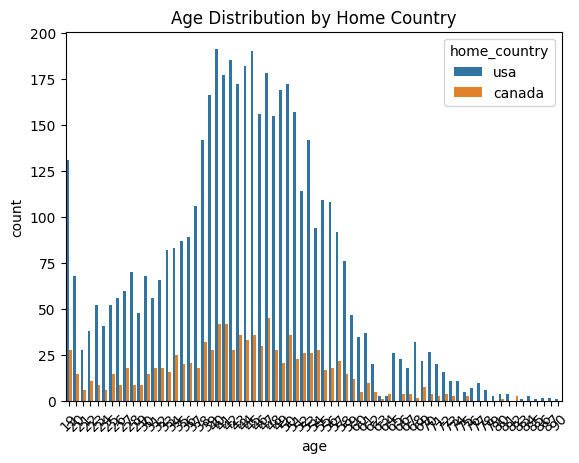

In [6]:
# Plot all countries with hue
sns.countplot(data=user_features_all,
              x='age',
              hue='home_country')
plt.title('Age Distribution by Home Country')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

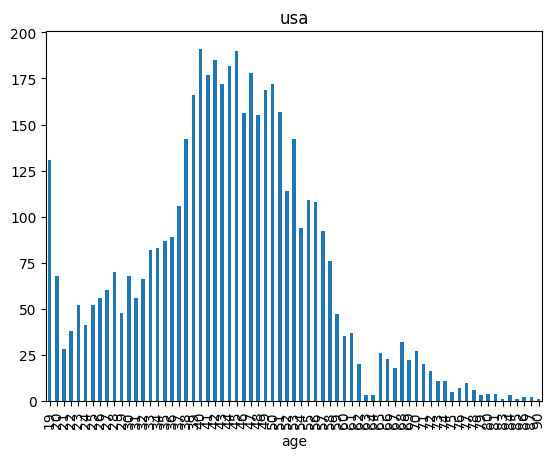

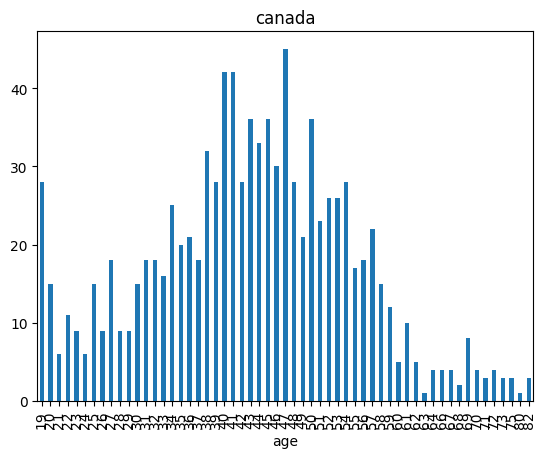

In [20]:
for country in user_features_all['home_country'].value_counts().index:
    user_features_all[user_features_all['home_country'] == country]['age'].value_counts().sort_index().plot(kind="bar")
    plt.title(country)
    plt.show()

In [23]:
user_features_all['gender'].value_counts(normalize=True)

gender
F    0.885161
M    0.112937
O    0.001902
Name: proportion, dtype: float64

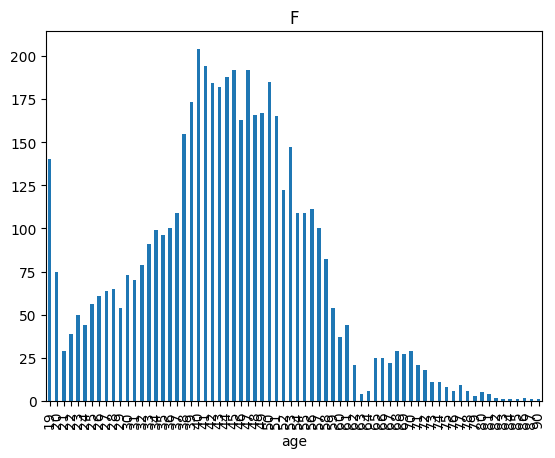

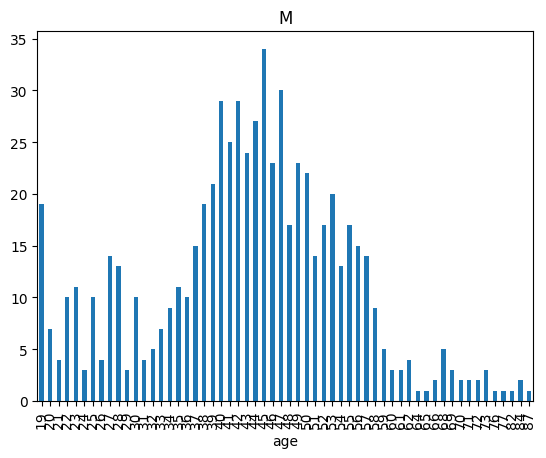

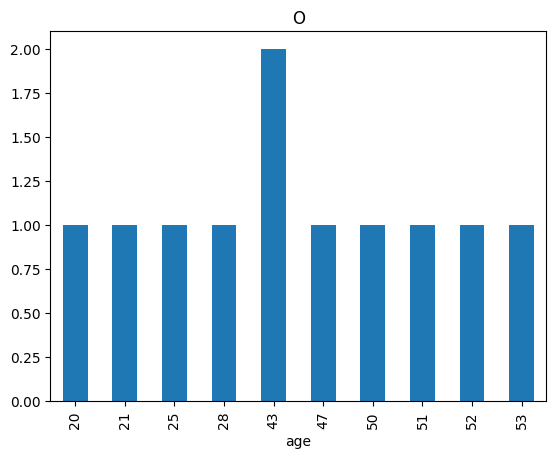

In [21]:
for gender in user_features_all['gender'].value_counts().index:
    user_features_all[user_features_all['gender'] == gender]['age'].value_counts().sort_index().plot(kind="bar")
    plt.title(gender)
    plt.show()

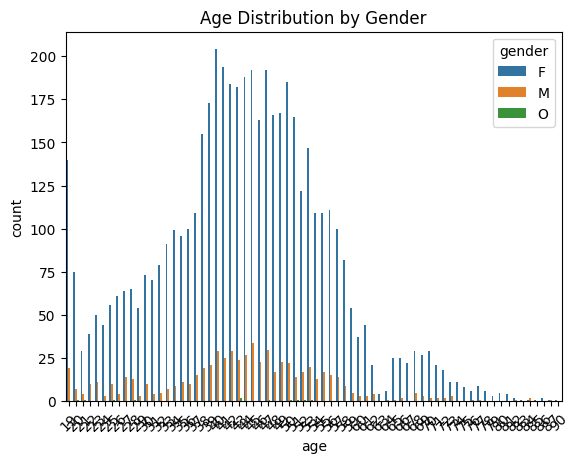

In [7]:
# Plot all countries with hue
sns.countplot(data=user_features_all,
              x='age',
              hue='gender')
plt.title('Age Distribution by Gender')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

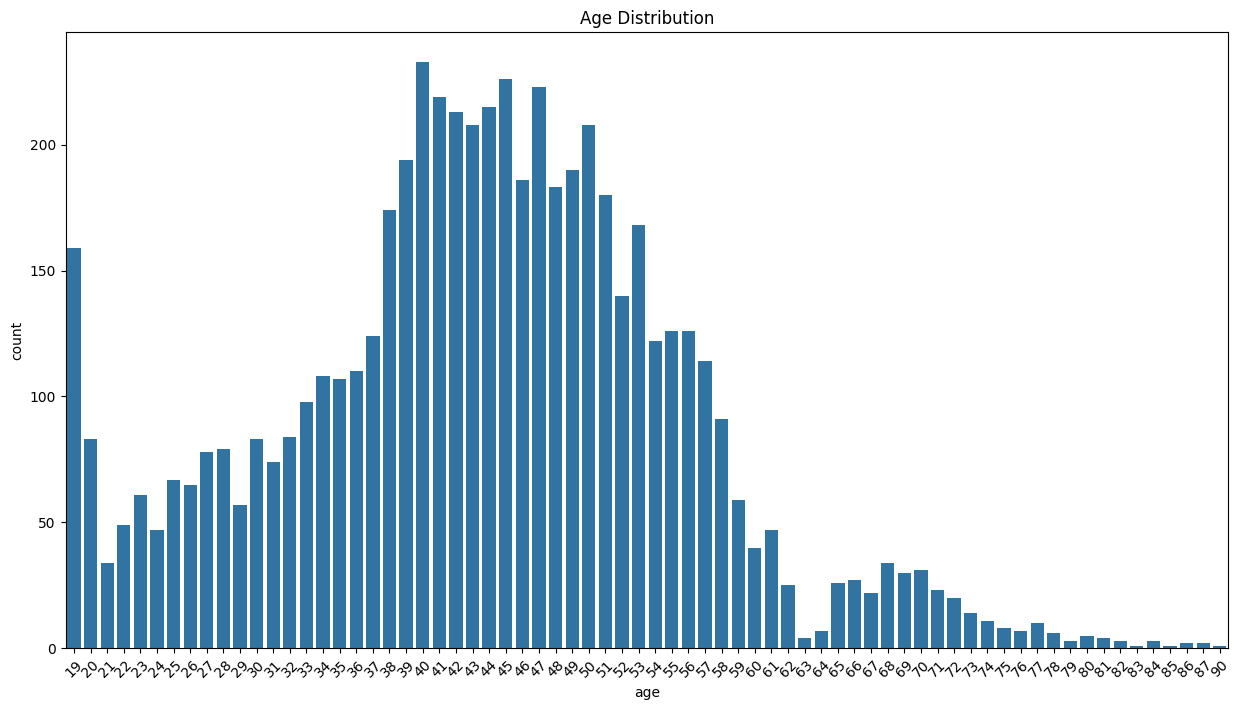

In [11]:
# Plot all countries with hue
plt.figure(figsize=(15, 8))
sns.countplot(data=user_features_all,
              x='age')
plt.title('Age Distribution')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

### Senior and Young Group
We can clearly see that the customer can be divided in 3 different groups according to age.
young group <21, senior group >63.

In [18]:
user_features

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,checked_bags_avg,overcarrier,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate
0,94883,F,True,False,usa,1505,54,1.5,0.5,False,2,0.0,2.0,2,1.0,0.250,0.0
1,101486,F,True,True,usa,1495,53,1.0,0.0,False,2,0.0,1.0,2,0.5,0.250,0.0
2,101961,F,True,False,usa,1495,45,1.0,0.4,False,5,0.0,5.0,5,1.0,0.625,0.2
3,106907,F,True,True,usa,1488,47,NaN,NaN,NaN,1,1.0,1.0,0,inf,0.000,NaN
4,118043,F,False,True,usa,1474,53,2.0,1.0,False,5,0.0,3.0,5,0.6,0.625,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,1063,51,1.5,0.0,False,2,0.0,2.0,2,1.0,0.250,0.5
5778,785186,F,True,True,usa,1061,46,1.0,0.0,False,2,0.0,2.0,2,1.0,0.250,0.0
5779,792549,F,False,False,usa,1058,48,1.0,0.5,False,4,0.0,4.0,4,1.0,0.500,0.0
5780,811077,F,True,True,usa,1052,47,1.0,0.0,False,1,0.0,1.0,1,1.0,0.125,0.0


In [19]:
senior_group = user_features_all[user_features_all['age'] >= 63].copy()

In [20]:
young_group = user_features_all[user_features_all['age'] < 21].copy()

Created Senior and Young group, we keep the rest for further analysis.

In [21]:
user_features = user_features_all[(user_features_all['age'] >= 21) & (user_features_all['age'] < 63)].copy()

In [24]:
user_features.shape

(5235, 17)

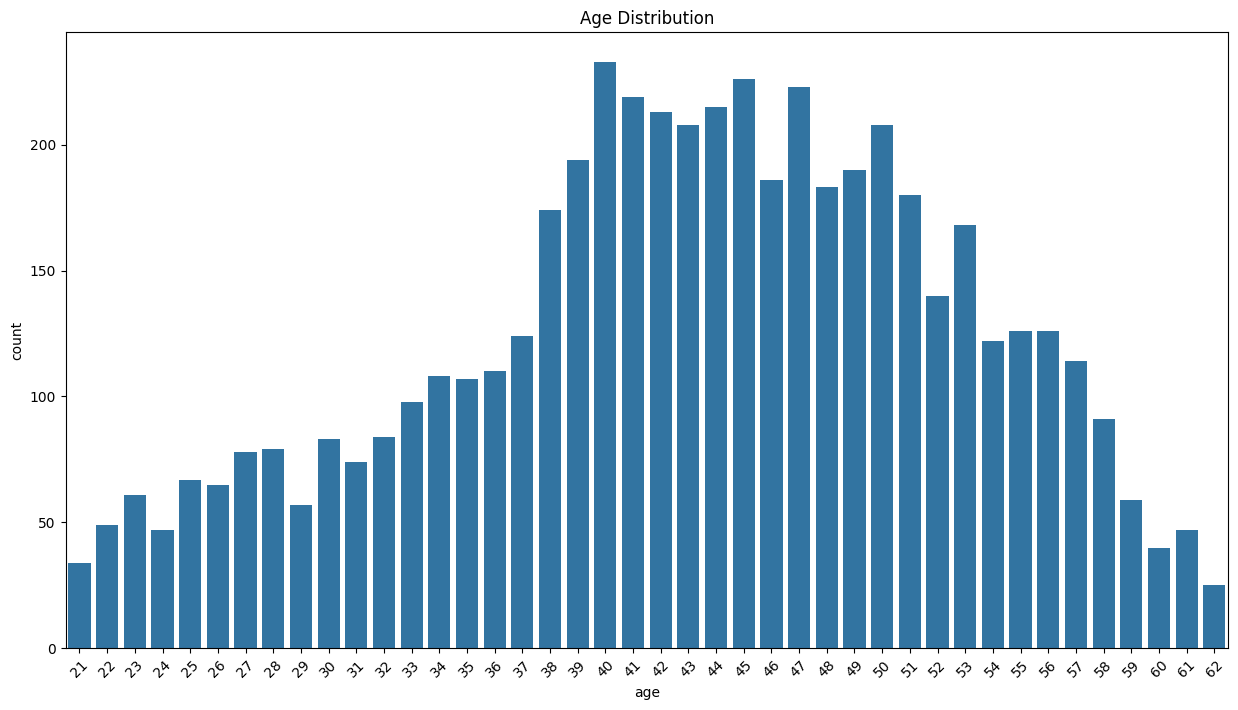

In [22]:
# Plot all countries with hue
plt.figure(figsize=(15, 8))
sns.countplot(data=user_features,
              x='age')
plt.title('Age Distribution')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

In [25]:
user_features_all

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,checked_bags_avg,overcarrier,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate
0,94883,F,True,False,usa,1505,54,1.5,0.5,False,2,0.0,2.0,2,1.0,0.250,0.0
1,101486,F,True,True,usa,1495,53,1.0,0.0,False,2,0.0,1.0,2,0.5,0.250,0.0
2,101961,F,True,False,usa,1495,45,1.0,0.4,False,5,0.0,5.0,5,1.0,0.625,0.2
3,106907,F,True,True,usa,1488,47,NaN,NaN,NaN,1,1.0,1.0,0,inf,0.000,NaN
4,118043,F,False,True,usa,1474,53,2.0,1.0,False,5,0.0,3.0,5,0.6,0.625,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,1063,51,1.5,0.0,False,2,0.0,2.0,2,1.0,0.250,0.5
5778,785186,F,True,True,usa,1061,46,1.0,0.0,False,2,0.0,2.0,2,1.0,0.250,0.0
5779,792549,F,False,False,usa,1058,48,1.0,0.5,False,4,0.0,4.0,4,1.0,0.500,0.0
5780,811077,F,True,True,usa,1052,47,1.0,0.0,False,1,0.0,1.0,1,1.0,0.125,0.0


### Family Travelers

In [37]:
family_traveler_group = user_features[(user_features['has_children'])&(user_features['married'])&(user_features["age"]<40)].copy()

In [41]:
~((user_features['has_children'])&(user_features['married'])&(user_features["age"]<40))

0       True
1       True
2       True
3       True
4       True
        ... 
5777    True
5778    True
5779    True
5780    True
5781    True
Length: 5073, dtype: bool

In [39]:
user_features = user_features[~((user_features['has_children'])&(user_features['married'])&(user_features["age"]<40))].copy()